In [1]:
%matplotlib inline
import torch
from torch.distributions import multinomial
import matplotlib.pyplot as plt

In [2]:
fair_probs=torch.ones([6])/6
multinomial.Multinomial(1,fair_probs).sample()

tensor([0., 0., 0., 0., 0., 1.])

In [3]:
multinomial.Multinomial(10,fair_probs).sample()

tensor([1., 2., 2., 2., 2., 1.])

In [4]:
counts=multinomial.Multinomial(1000,fair_probs).sample()
counts/1000

tensor([0.1600, 0.1820, 0.1660, 0.1560, 0.1740, 0.1620])

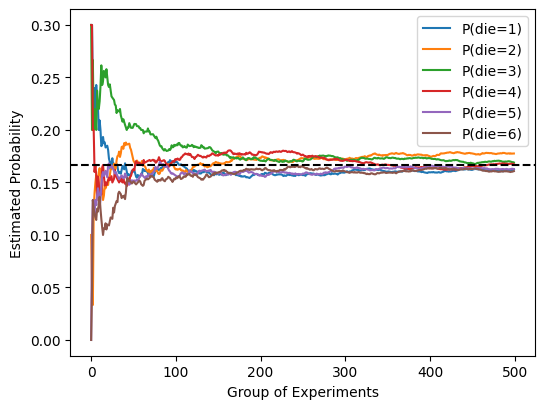

In [6]:
counts=multinomial.Multinomial(10,fair_probs).sample((500,))
cum_counts=counts.cumsum(dim=0)
estimates=cum_counts/cum_counts.sum(dim=1,keepdim=True)
plt.figure(figsize=(6,4.5))
for i in range(6):
  plt.plot(estimates[:,i].numpy(),label=("P(die="+str(i+1)+")"))
plt.axhline(y=0.167,color='black',linestyle='dashed')
plt.gca().set_xlabel("Group of Experiments")
plt.gca().set_ylabel("Estimated Probability")
plt.legend()
plt.show()
